In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,auc
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv(r"C:\Users\Pratham\Desktop\Credit_Card_Fraud_Detection\creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Perform EDA (Exploratory Data Analysis)

In [6]:
# Check Dataset Shape
df.shape

(284807, 31)

In [7]:
# Check Missing Values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
# There are total 17918 rows and in that each feature have 1 missing value except 5 feature so there is so there is total 26 column which has missing value to solve this there are 3 different approach

In [9]:
# 1. df = df.dropna()
# 2. df.fillna(df.median(),inplace=True)
# 3. Ignore it because in case of 15k rows 20 or less than 20 rows has missing value which is almost negligible

# But we are going with systematic approach we are following the 2 approach

In [10]:
df.fillna(df.median(),inplace=True)

In [11]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
# Check Class Distribution
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [14]:
# Visualizations

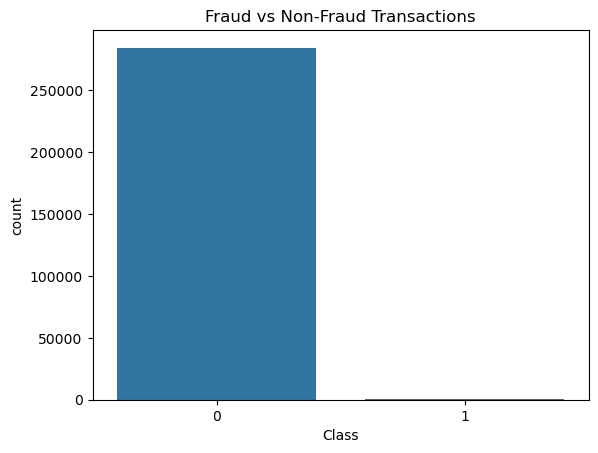

In [15]:
sns.countplot(x='Class',data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

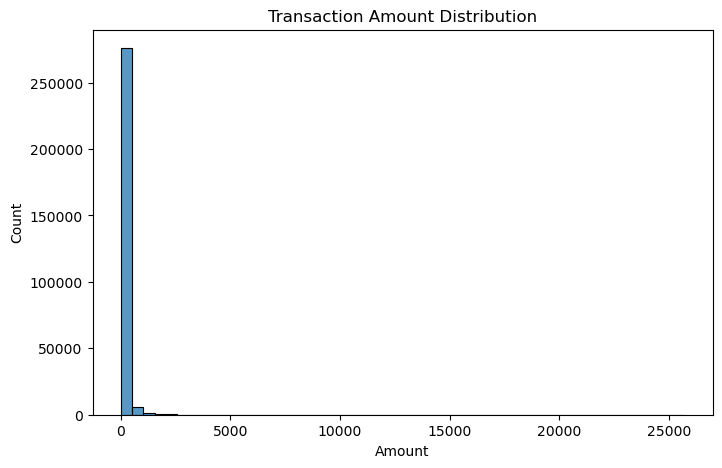

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'],bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

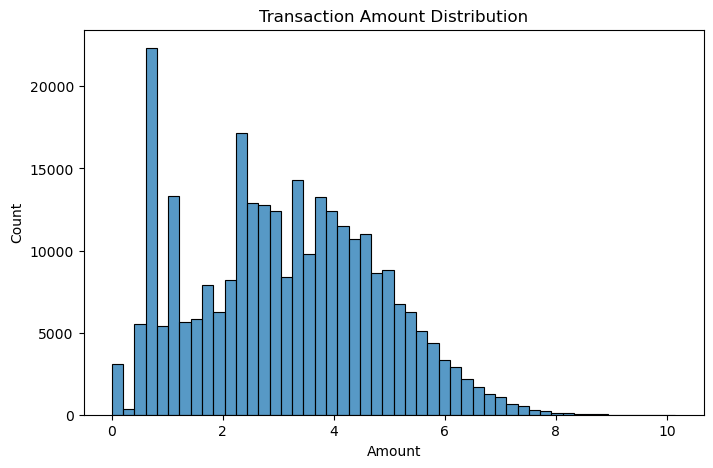

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['Amount']),bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

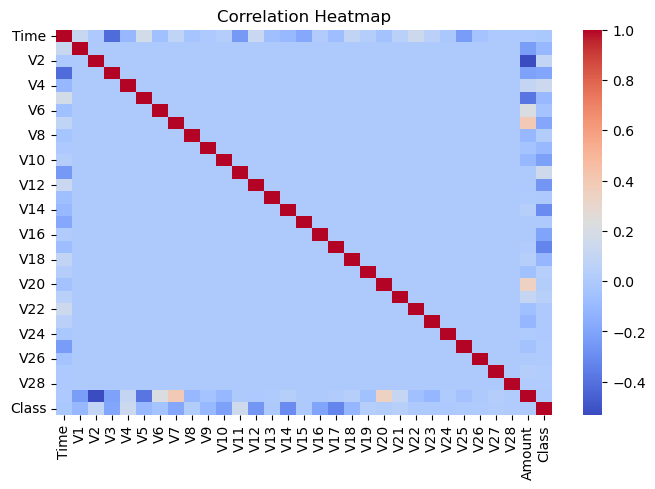

In [18]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
# Separate Features and Target

In [20]:
X = df.drop('Class',axis=1)
y = df['Class']

In [21]:
# Divide into training and testing

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [23]:
# Handle Imbalanced data with the help of SMOTE (Synthetic Minority Oversampling Technique)

In [24]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res,y_train_res = smote.fit_resample(X_train,y_train)

In [25]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [26]:
pd.Series(y_train_res).value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [27]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



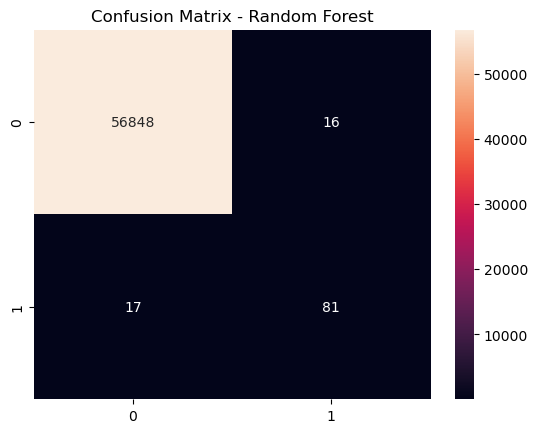

In [28]:
cm = confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

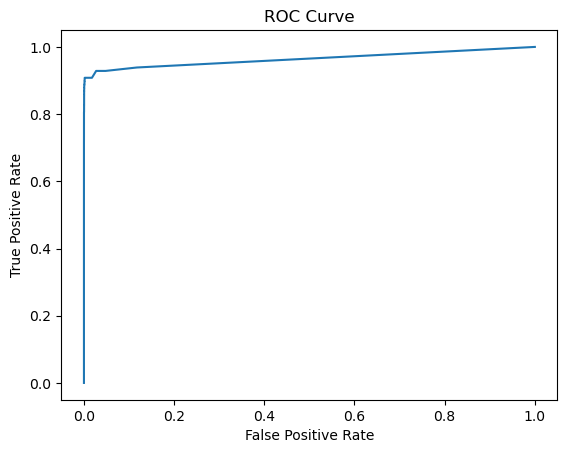

In [29]:
y_prob = rf.predict_proba(X_test)[:,1]
fpr,tpr,_ = roc_curve(y_test,y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [30]:
y_prob = rf.predict_proba(X_test)[:,1]
y_pred_custom = (y_prob>0.3).astype(int)

In [31]:
importance = rf.feature_importances_
feature_importance = pd.Series(importance,index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

V14    0.217013
V10    0.119797
V4     0.116789
V12    0.107501
V17    0.086248
V3     0.070860
V11    0.050472
V16    0.040096
V2     0.038845
V9     0.028277
dtype: float64

In [32]:
joblib.dump(rf,"fraud_model.pkl")

['fraud_model.pkl']

In [33]:
import joblib

model = joblib.load("fraud_model.pkl")
print(model.n_features_in_)

30


In [34]:
df.drop("Class", axis=1).head(5).to_csv("sample_test.csv", index=False)

In [35]:
df.drop("Class", axis=1).head(10).to_csv("sample_test_1.csv", index=False)

In [36]:
# Extract only fraud transactions
fraud_rows = df[df["Class"] == 1]

# Take one fraud sample
fraud_sample = fraud_rows.drop("Class", axis=1).iloc[[0]]

# Save it
fraud_sample.to_csv("fraud_test.csv", index=False)

In [37]:
# Combine X_test and y_test
test_data = X_test.copy()
test_data["Class"] = y_test.values

# Extract fraud row
fraud_sample = test_data[test_data["Class"] == 1].drop("Class", axis=1).iloc[[0]]

# Save it
fraud_sample.to_csv("fraud_test_1.csv", index=False)